# PS-S06E06: XGBoost

This notebook tackles the [**Playground Series – Season 6, Episode 6: Predicting Stellar Class**](https://www.kaggle.com/competitions/playground-series-s6e6), a competition focused on predicting a class label (`QSO`, `STAR`, and `GALAXY`) for the  target, based on features describing the position, light intensity across SDSS photometric bands, redshift, spectral type, and galaxy population for each observed object.

## Introduction

**XGBoost** is well-suited to this tabular classification task. It handles the mix of numerical photometric features and categorical features (`spectral_type`, `galaxy_population`) natively via , includes L1/L2 regularization to prevent overfitting, and pairs well with  to maintain class balance across folds.

The target is a three-class problem (`QSO`, `STAR`, and `GALAXY`), evaluated by **Balanced Accuracy** to account for any class imbalance. Categorical features are ordinal- or unordered-encoded in the  and passed as  dtype directly to XGBoost.

This notebook is one of several exploring different models for this challenge. The EDA was performed in: [**PS-S06E06: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e06-eda).

In [1]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.feature_selection import RFECV
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e06_feature_engineering import FeatureFactory
from ps_s06e06_model_visualizer import ModelVisualizer
from ps_s06e06_experiment_setup import ExperimentSetup

# Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'class'

# Class label mapping  (must be consistent everywhere)
target_mapping = {'QSO': 0, 'STAR': 1, 'GALAXY': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}

# Use GPU for tree building if available
USE_GPU = True

# Recursive Feature Elimination
PERFORM_RFE = False

# Optuna hyperparameter tuning
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id   alpha  delta      u      g      r      i      z  redshift  \
0   0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409   
1   1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158   
2   2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824   
3   3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536   
4   4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556   

  spectral_type galaxy_population   class  
0             M      Red_Sequence  GALAXY  
1             M      Red_Sequence  GALAXY  
2           O/B        Blue_Cloud     QSO  
3             M      Red_Sequence  GALAXY  
4             M      Red_Sequence  GALAXY  


In [4]:
test_df = helper.read_dataset('test')

TEST DATASET

       id   alpha  delta      u      g      r      i      z  redshift  \
0  577347 120.720 23.924 23.668 21.952 21.086 20.180 19.202     0.429   
1  577348 219.414 42.172 24.903 22.339 20.732 19.860 19.688     0.867   
2  577349 173.569 -1.756 19.428 18.475 17.551 16.571 16.177     0.224   
3  577350 184.904 -1.411 23.121 21.527 20.670 20.418 20.699     0.067   
4  577351 222.488 15.381 25.094 22.644 21.123 19.440 19.094     0.977   

  spectral_type galaxy_population  
0           G/K      Red_Sequence  
1             M      Red_Sequence  
2           G/K        Blue_Cloud  
3           G/K      Red_Sequence  
4             M      Red_Sequence  


## Feature Engineering

In [5]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'encoding',       # Cast spectral_type and galaxy_population to category dtype
    'colors',         # SDSS photometric color indices (u-g, g-r, r-i, i-z, etc.)
    'ratios',         # SED shape features: mean/std magnitude, spectral slope
    'redshift',       # Redshift-derived features and color×redshift interactions
    'position',       # Sky-coordinate Cartesian projection and |delta|
    'interactions',   # Higher-order cross-feature products
]

In [6]:
print('Performing initial feature engineering.')

# Encode target labels: QSO=0, STAR=1, GALAXY=2
y = training_df[TARGET].map(target_mapping).astype(int)

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 11
New Feature Count: 39
    alpha  delta      u      g      r      i      z  redshift spectral_type  \
0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409             M   
1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158             M   
2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824           O/B   
3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536             M   
4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556             M   

  galaxy_population  u_minus_g  g_minus_r  r_minus_i  i_minus_z  u_minus_r  \
0      Red_Sequence      3.577      1.538      1.101      0.636      5.114   
1      Red_Sequence      1.691      1.500      0.361      0.440      3.191   
2        Blue_Cloud     -0.044     -0.093      0.589      0.025     -0.137   
3      Red_Sequence      2.254      2.033      0.652      0.451      4.287   
4      Red_Sequence      2.231      1.237      0.33

## Optional Recursive Feature Elimination and Optuna Training

If  is , Recursive Feature Elimination with Cross-Validation (RFECV) is performed on a numeric-encoded snapshot of the feature-engineered training set. It iteratively removes the weakest feature and re-scores until the optimal subset is found. The selected feature names are then applied per-fold during training to prevent leakage.

If  is , an Optuna study maximizes Balanced Accuracy over the full 5-fold CV loop. Otherwise, a previously derived best-params dict is used directly.

In [7]:
n_jobs = 1 if USE_GPU else -1

X_rfe = X.copy()

# Convert all object and category columns to integer codes for RFE
cat_cols_rfe = X_rfe.select_dtypes(include=['category', 'object']).columns
for col in cat_cols_rfe:
    X_rfe[col] = X_rfe[col].astype('category').cat.codes

if PERFORM_RFE:
    warnings.filterwarnings('ignore', category=UserWarning, module='xgboost.core')

    clf = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        tree_method='hist',
        enable_categorical=False,
        device='cpu',
        objective='multi:softprob',
        num_class=3,
        random_state=seed,
        n_jobs=n_jobs
    )

    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
        scoring='balanced_accuracy',
        min_features_to_select=10,
        n_jobs=n_jobs,
        verbose=1
    )

    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    rfecv.fit(X_rfe, y)

    print(f'Optimal number of features: {rfecv.n_features_}')

    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross-validation score (Balanced Accuracy)')
    plt.plot(
        range(rfecv.min_features_to_select,
              len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
        rfecv.cv_results_['mean_test_score']
    )
    plt.title('RFE Performance for Stellar Class')
    plt.show()

    optimal_cols = X_rfe.columns[rfecv.support_]
else:
    print('Using all columns as optimal features.')
    optimal_cols = X_rfe.columns

print('Optimal Features:')
print(optimal_cols.tolist())

Using all columns as optimal features.
Optimal Features:
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_minus_g', 'g_minus_r', 'r_minus_i', 'i_minus_z', 'u_minus_r', 'u_minus_z', 'g_minus_z', 'g_minus_i', 'color_range', 'blue_red_slope', 'color_curvature', 'mean_mag', 'std_mag', 'outer_to_r', 'redshift_log1p', 'redshift_sq', 'is_near_zero_z', 'is_high_z', 'z_x_u_g', 'z_x_g_r', 'z_x_color_range', 'pos_x', 'pos_y', 'pos_z', 'abs_delta', 'z_x_mean_mag', 'ug_x_gr', 'gr_x_ri', 'std_mag_x_z']


In [8]:
print("Precomputing fold-wise FE for Optuna (once)...")
skf_cache = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []

for fold, (train_idx, val_idx) in enumerate(skf_cache.split(training_df, y)):
    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold   = training_df.iloc[val_idx]
    y_val_fold   = y.iloc[val_idx]

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans   = fe.transform(X_val_fold)

    final_cols = [c for c in list(optimal_cols) if c in X_train_trans.columns]
    X_train_trans = X_train_trans[final_cols]
    X_val_trans   = X_val_trans[final_cols]

    # Cast categoricals once at cache time
    for col in X_train_trans.select_dtypes(include=['object']).columns:
        X_train_trans[col] = X_train_trans[col].astype('category')
        X_val_trans[col]   = X_val_trans[col].astype('category')

    fold_cache.append((X_train_trans, y_train_fold, X_val_trans, y_val_fold, val_idx))

print(f"Cached {len(fold_cache)} folds.")

Precomputing fold-wise FE for Optuna (once)...
Cached 5 folds.


In [9]:
def balanced_accuracy_xgb(y_pred, dtrain):
    y_true = dtrain.get_label().astype(int)
    n_samples = len(y_true)
    n_classes = 3
    # y_pred is flat (n_samples * n_classes,) in row-major order
    probs = y_pred.reshape(n_samples, n_classes)
    preds = np.argmax(probs, axis=1)
    score = balanced_accuracy_score(y_true, preds)
    return 'balanced_accuracy', score

In [10]:
def objective(trial):

    param = {
        # Core booster params
        'n_estimators': 8000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.06, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 7),
        'min_child_weight': trial.suggest_float('min_child_weight', 10.0, 60.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.75, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.70, 0.95),

        # Regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 10.0, 100.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 3.0),

        # Tree structure
        'grow_policy': 'lossguide',

        # Boilerplate
        'objective': 'multi:softprob',
        'eval_metric': 'mlogloss',
        'custom_metric': balanced_accuracy_xgb,
        'num_class': 3,
        'tree_method': 'hist',
        'device': 'cuda' if USE_GPU else 'cpu',
        'enable_categorical': True,
        'early_stopping_rounds': 50,
        'random_state': seed,
        'n_jobs': n_jobs
    }

    cols_to_keep = list(optimal_cols)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    oof_preds = np.zeros(len(y), dtype=int)

    for fold, (X_train_trans, y_train_fold, X_val_trans, y_val_fold, val_idx) in enumerate(fold_cache):
        model = xgb.XGBClassifier(**param)
        weights = compute_sample_weight('balanced', y_train_fold)
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            sample_weight=weights,
            verbose=False
        )
        preds = model.predict(X_val_trans)
        oof_preds[val_idx] = preds
    
        fold_score = balanced_accuracy_score(y_val_fold, preds)
        trial.report(fold_score, step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return balanced_accuracy_score(y, oof_preds)


In [11]:
xgb_best_params = {
    'learning_rate': 0.0524275013316105,
    'max_depth': 7,
    'min_child_weight': 14.303101610784235,
    'subsample': 0.8490215357771442,
    'colsample_bytree': 0.7282162752257856,
    'reg_alpha': 0.16797250061587782,
    'reg_lambda': 11.471396883342349,
    'gamma': 1.036404258399409
}

if PERFORM_OPTUNA_TUNING:
    print('Starting XGBoost Optuna Optimization...')

    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)

    study_xgb = optuna.create_study(
        direction='maximize',
        study_name='xgb_predict_stellar_class_optuna',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True,       # models parameter correlations — helps here since
        )                            # lambda/mcw/lr are correlated in the best trials
    )
    
    # Seed with current best so trial 0 isn't cold-start
    study_xgb.enqueue_trial(xgb_best_params)

    study_xgb.optimize(
        objective,
        n_trials=50,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )

    print('Best Trial:')
    print(f'   Balanced Accuracy: {study_xgb.best_value:.5f}')
    print('   Params: ', study_xgb.best_params)

    xgb_best_params = study_xgb.best_params
else:
    print('Using placeholder params:')
    print('  Params: ', xgb_best_params)

[I 2026-06-06 14:59:11,196] A new study created in memory with name: xgb_predict_stellar_class_optuna


Starting XGBoost Optuna Optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-06 15:02:39,702] Trial 0 finished with value: 0.9656663845134092 and parameters: {'learning_rate': 0.058651950300984426, 'max_depth': 6, 'min_child_weight': 27.657651651393586, 'subsample': 0.8775689964006245, 'colsample_bytree': 0.7167802090283875, 'reg_alpha': 0.09759030681724434, 'reg_lambda': 35.82309038777263, 'gamma': 1.2252120453627298}. Best is trial 0 with value: 0.9656663845134092.
[I 2026-06-06 15:05:36,788] Trial 1 finished with value: 0.9634066335799742 and parameters: {'learning_rate': 0.03778964099012358, 'max_depth': 4, 'min_child_weight': 51.34103657498562, 'subsample': 0.9004725073679622, 'colsample_bytree': 0.7771883891912098, 'reg_alpha': 1.1584419530268095, 'reg_lambda': 99.35997514004221, 'gamma': 1.9943964241639978}. Best is trial 0 with value: 0.9656663845134092.
[I 2026-06-06 15:10:11,279] Trial 2 finished with value: 0.9643232422674642 and parameters: {'learning_rate': 0.025067087175128917, 'max_depth': 5, 'min_child_weight': 29.148650996629, 'subsa

## Model Training

In [13]:
xgb_tuned_params = {
    **xgb_best_params,
    'n_estimators': 20000,
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'custom_metric': balanced_accuracy_xgb,
    'num_class': 3,
    'n_jobs': n_jobs,
    'random_state': seed,
    'enable_categorical': True,
    'early_stopping_rounds': 200,
    'tree_method': 'hist',
    'device': 'cuda' if USE_GPU else 'cpu',
}

print('Final XGBoost CV Training with OOF / Test probabilities')
print('=======================================================')
print('Parameters used for training:')
print(xgb_tuned_params)

cols_to_keep = list(optimal_cols)

n_folds = 5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

eval_results = []
models = []

oof_probs = np.zeros((len(y), 3))
test_probs = np.zeros((len(test_df), 3))
oof_preds = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y)):
    print(f'Starting processing of fold {fold+1}')

    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold   = training_df.iloc[val_idx]
    y_val_fold   = y.iloc[val_idx]

    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans   = fe_fold.transform(X_val_fold)
    X_test_trans  = fe_fold.transform(test_df)

    final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
    if not final_cols:
        raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
    X_train_trans = X_train_trans[final_cols]
    X_val_trans   = X_val_trans[final_cols]
    X_test_trans  = X_test_trans[final_cols]

    obj_cols = X_train_trans.select_dtypes(include=['object']).columns.tolist()
    for col in obj_cols:
        X_train_trans[col] = X_train_trans[col].astype('category')
        X_val_trans[col]   = X_val_trans[col].astype('category')
        X_test_trans[col]  = X_test_trans[col].astype('category')

    model = xgb.XGBClassifier(**xgb_tuned_params)
    weights = compute_sample_weight('balanced', y_train_fold)

    model.fit(
        X_train_trans, y_train_fold,
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        sample_weight=weights,
        verbose=500
    )

    eval_results.append(model.evals_result())
    models.append(model)

    probs = model.predict_proba(X_val_trans)
    preds = model.predict(X_val_trans)

    oof_probs[val_idx] = probs
    oof_preds[val_idx] = preds

    fold_score = balanced_accuracy_score(y_val_fold, preds)
    print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f} (best_iteration={model.best_iteration})')

    test_probs += model.predict_proba(X_test_trans) / n_folds

overall_score = balanced_accuracy_score(y, oof_preds)
print(f"Overall Balanced Accuracy Score: {overall_score:.5f}")

Final XGBoost CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.0524275013316105, 'max_depth': 7, 'min_child_weight': 14.303101610784235, 'subsample': 0.8490215357771442, 'colsample_bytree': 0.7282162752257856, 'reg_alpha': 0.16797250061587782, 'reg_lambda': 11.471396883342349, 'gamma': 1.036404258399409, 'n_estimators': 20000, 'objective': 'multi:softprob', 'eval_metric': 'mlogloss', 'custom_metric': <function balanced_accuracy_xgb at 0x77f8a32c0680>, 'num_class': 3, 'n_jobs': 1, 'random_state': 10301, 'enable_categorical': True, 'early_stopping_rounds': 200, 'tree_method': 'hist', 'device': 'cuda'}
Starting processing of fold 1
[0]	validation_0-mlogloss:1.03308	validation_1-mlogloss:1.03314
[500]	validation_0-mlogloss:0.09351	validation_1-mlogloss:0.10838
[1000]	validation_0-mlogloss:0.08184	validation_1-mlogloss:0.10451
[1500]	validation_0-mlogloss:0.07806	validation_1-mlogloss:0.10356
[2000]	validation_0-mlogloss:0.07580	validation_1-mloglo

## Visualizing Model Performance
Four plots diagnose the health of the trained classifier.

### Learning Curves (Train vs. Validation Log-Loss)
This plot shows  over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Early stopping terminates training once the validation loss plateaus.

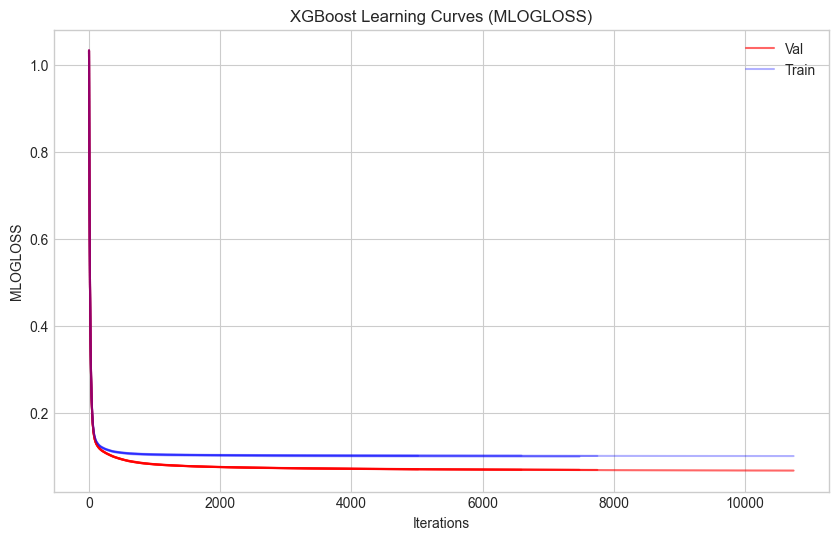

In [14]:
mviz = ModelVisualizer(model_name='XGBoost')

mviz.plot_learning_curves(eval_results, metric='mlogloss')

### Feature Importance
This bar chart ranks features by average gain across all folds.
* **Validation check:** `redshift`, `redshift_sq`, `redshift_log1p`, and `is_high_z` should dominate.  `redshift` is the single strongest discriminator in the SDSS stellar classification literature. If none of these appear near the top, something is wrong upstream.
* **Color check:** Consecutive color indices (`g_minus_z`, `u_minus_r`, `g_minus_i`, etc.) should rank highly. If raw magnitudes (`u`, `g`, `r`, `i`, `z`) outrank the color features, consider whether the `colors` strategy is active in `fe_strategies`.
* **Leakage check:** `id` must not appear in the chart at all. `alpha` and `delta` should rank low unless the `position` strategy is active, which the chart confirms is the case here.

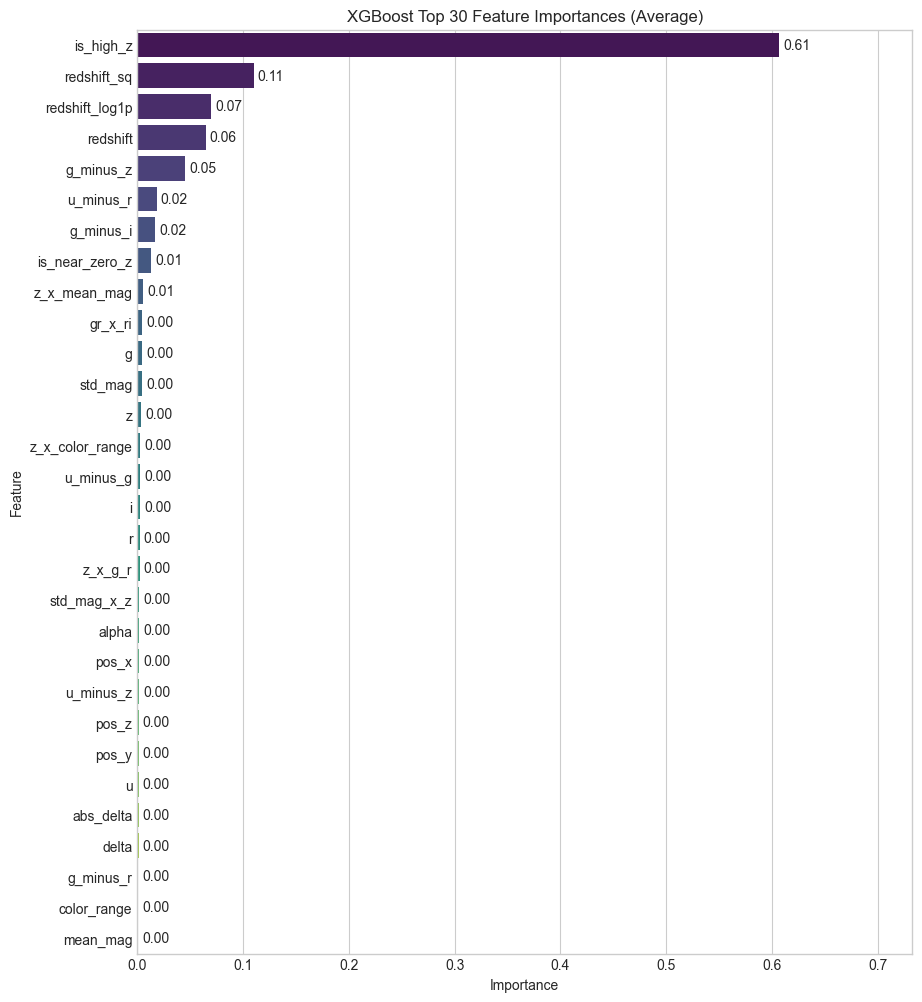

In [15]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Overlays the distribution of true class labels against OOF predicted labels (integer-encoded: QSO=0, STAR=1, GALAXY=2). A large divergence on one class suggests the model is systematically misclassifying that stellar type.

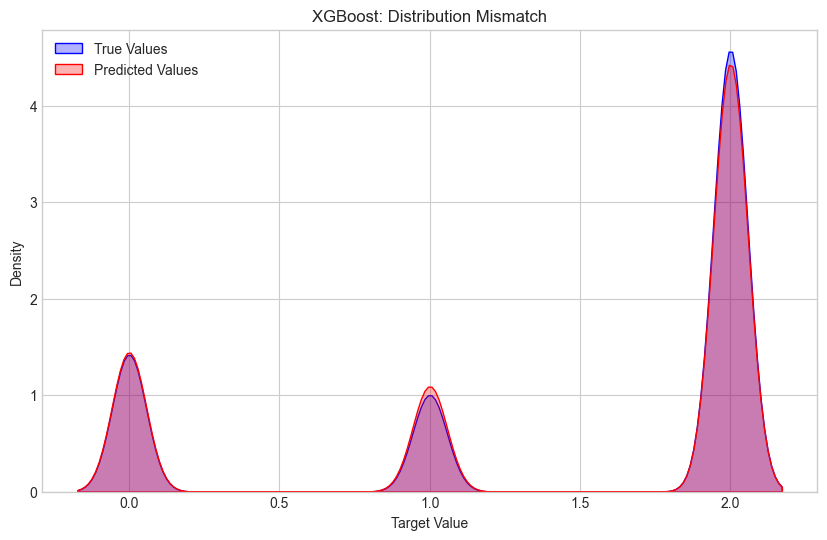

In [16]:
mviz.plot_distribution_mismatch(y_true=y, y_preds=oof_preds)

### Confusion Matrix
A normalized confusion matrix across the three stellar classes.
* **Diagonal:** Correct classifications for each class. All three should be high.
* **QSO column (0):** QSOs share photometric colors with both galaxies and stars at certain redshifts; off-diagonal entries here are the most common failure mode.
* **STAR row (1):** Stars are near-zero redshift objects and are generally the easiest to separate. High off-diagonal values here warrant investigation.

Normalized confusion matrix


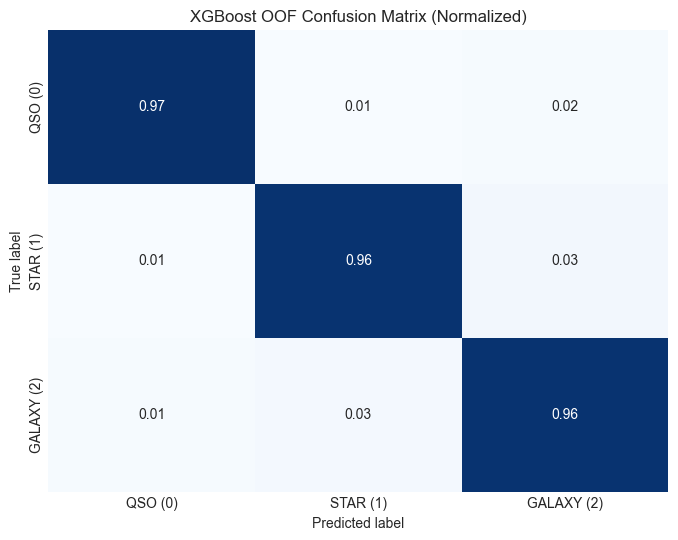

In [17]:
y_pred_class = np.argmax(oof_probs, axis=1)

mviz.plot_confusion_matrix(
    y_true=y,
    y_pred=y_pred_class,
    classes=['QSO (0)', 'STAR (1)', 'GALAXY (2)'],
    normalize=True,
    title='XGBoost OOF Confusion Matrix (Normalized)'
)

### Multiclass ROC Curve (One-vs-Rest)
Each class is treated as the positive class in turn. The AUC for each curve measures how well the model separates that class from the other two. All three curves should sit well above the diagonal; a sagging QSO curve is the most common weak point in stellar classification tasks.

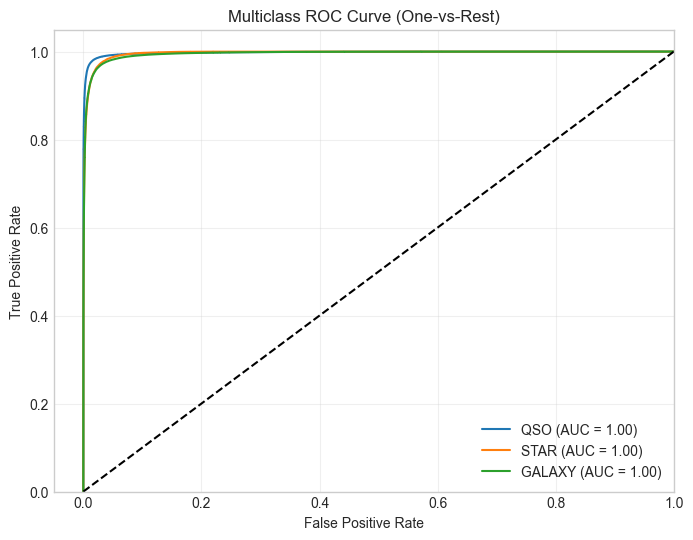

In [18]:
mviz.plot_multiclass_roc_curve(y_true=y, y_score=oof_probs)

## Prepare Submission

The competition requires the hard predicted class label (, , or ) for each row in the test set. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [19]:
submission_df = helper.read_dataset('submission')

numeric_preds = np.argmax(test_probs, axis=1)

# Map numeric predictions back to string class labels
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY


In [20]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) and averaged test-set probabilities are saved for downstream ensembling (blending or stacking).

For this three-class task we save the full probability distribution across , , and  rather than just the argmax labels. Raw probabilities are essential for:

- **Weighted Blending**: Averaging confidence scores across XGBoost, LightGBM, and CatBoost models.
- **Stacking**: Using these probabilities as meta-features for a secondary model.
- **Calibration Analysis**: Verifying that predicted confidence aligns with actual class frequencies.

In [21]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Column names match the class label mapping: QSO=0, STAR=1, GALAXY=2
prob_cols = ['prob_qso', 'prob_star', 'prob_galaxy']

# OOF probabilities
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_df = pd.concat([
    pd.DataFrame({'id': training_df['id'].values, 'target': y.values}),
    oof_prob_df
], axis=1)
oof_df.to_csv(f'{output_dir}/xgb_oof_probs.csv', index=False)

# Test probabilities
test_prob_df = pd.concat([
    pd.DataFrame({'id': test_df['id'].values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/xgb_test_probs.csv', index=False)

print(f'Saved for ensembling: {output_dir}/xgb_oof_probs.csv {output_dir}/xgb_test_probs.csv')

Saved for ensembling: predictions/xgb_oof_probs.csv predictions/xgb_test_probs.csv
